# AI61201: Visual Computing with AI/ML (Autumn 2026)
### **Programming Assignment 2:** Spatial Domain Image Transformations (20 Marks)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Directional Unsharp Masking (6 Marks)

Use `image_one.jpg` (Assignment-2 resources) 

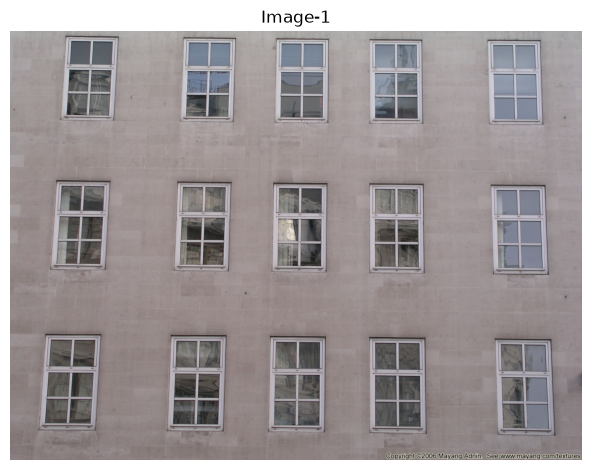

In [2]:
img1 = cv2.imread('resources/image_one.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

plt.imshow(img1)
plt.title("Image-1")
plt.axis("off")
plt.tight_layout()

### Task 1.1 Filter Design & Visualisation (3 Marks)

Design a Gaussian smoothing filter that performs directional smoothing to facilitate vertical edge sharpening using highboost filtering.
- Construct an anisotropic 2D Gaussian kernel of size 61×61. The smaller standard deviation is set to σ=0.5, and the ratio of the larger standard deviation to the smaller one is 40:1. Determine whether the kernel needs to be oriented horizontally or vertically to enhance vertical edges.
- Plot the level sets (contour plot) and display the heatmap of the designed Gaussian kernel.

In [3]:
# kernel specifications
kernel_size = 61
sigma_small = 0.5
sigma_ratio = 40

# vertical edge enhancement => strong smoothing across x, minimal smoothing along y
sigma_x = sigma_small * sigma_ratio
sigma_y = sigma_small

# generate coordinate space
centre = kernel_size // 2
x = np.arange(-centre, centre + 1)
y = np.arange(-centre, centre + 1)
x, y = np.meshgrid(x, y)

# anisotropic gaussian kernel
gaussian_kernel = (
    1 / (2 * np.pi * sigma_x * sigma_y)
    * np.exp(-(
        x**2 / (2 * sigma_x ** 2)
        + y**2 / (2 * sigma_y ** 2)
    ))
)
gaussian_kernel /= np.sum(gaussian_kernel)  # normalize the kernel

print("Kernel shape:", gaussian_kernel.shape)
print("Kernel sum  :", gaussian_kernel.sum())

Kernel shape: (61, 61)
Kernel sum  : 1.0


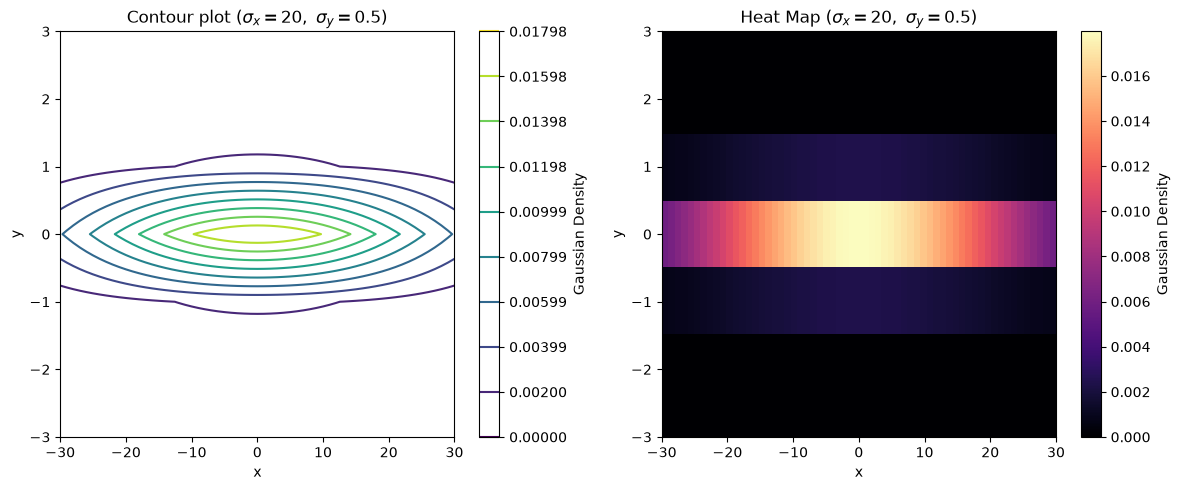

In [4]:
# determine the level set
levels = np.linspace(gaussian_kernel.min(), gaussian_kernel.max(), num=10)
plt.figure(figsize=(12, 5))

# contour plot
plt.subplot(1, 2, 1)
contours = plt.contour(x, y, gaussian_kernel, levels=levels)
plt.colorbar(contours, label="Gaussian Density")
plt.title(r"Contour plot ($\sigma_x=20,\ \sigma_y=0.5$)")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-3, 3)


# heatmap
plt.subplot(1, 2, 2)
plt.imshow(gaussian_kernel, extent=[x.min(), x.max(), y.min(), y.max()], origin="lower", aspect="auto", cmap="magma")
plt.colorbar(label="Gaussian Density")
plt.title(r"Heat Map ($\sigma_x=20,\ \sigma_y=0.5$)")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-3, 3)

plt.tight_layout()

### Task 1.2 Spatial Filtering (1 Mark)

Perform 2D convolution on the input image using `cv2.filter2D()` with your custom anisotropic kernel. Display the filtered (blurred) output.

In [5]:
# utility method to plot multiple images / channels in a layout
def display_images(rows, cols, title, channels, channel_names=['Before', 'After']):
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).flatten()
    fig.suptitle(title, fontsize=20)
    
    for i in range(len(channels)):
        if channels[i].ndim == 3 and channels[i].shape[2] == 3:
            axes[i].imshow(channels[i])                 # plot image in color
        else:
            axes[i].imshow(channels[i], cmap='gray')    # plot single channel in grayscale
        axes[i].set_title(channel_names[i])
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

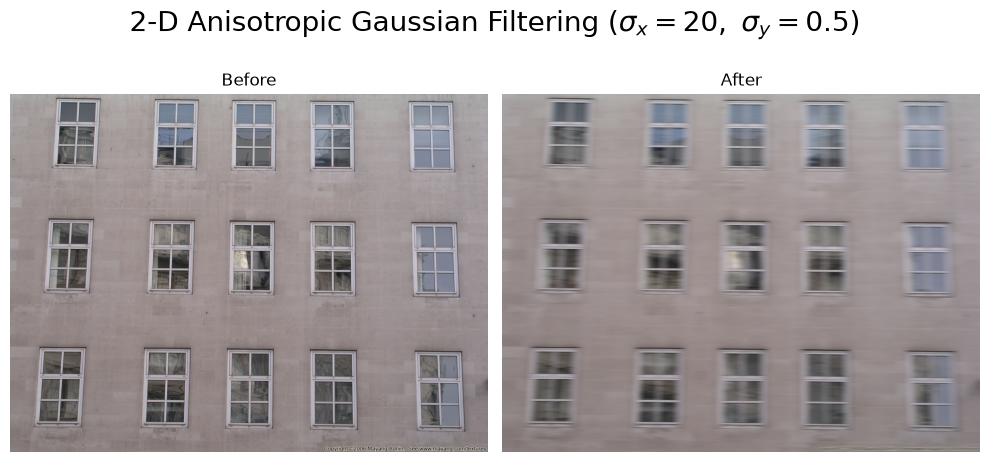

In [6]:
# perform 2D convolution
# ddepth = -1 => output image has same data depth as input image
blur_img = cv2.filter2D(img1, -1, gaussian_kernel)

display_images(
    rows=1, cols=2,
    title=r"2-D Anisotropic Gaussian Filtering ($\sigma_x=20,\ \sigma_y=0.5$)",
    channels=[img1, blur_img]
)

### Task 1.3 Unsharp Masking & High Boost Filtering (2 Marks)

- Compute the unsharp mask: ***Mask = InputImage - BlurredImage***
- Apply high boost filtering: ***SharpenedImage = InputImage + k x Mask*** (use `k=1.5`). 
- Display both the isolated mask and the final sharpened image. Briefly explain why vertical edges are sharpened while horizontal edges remain unaffected.

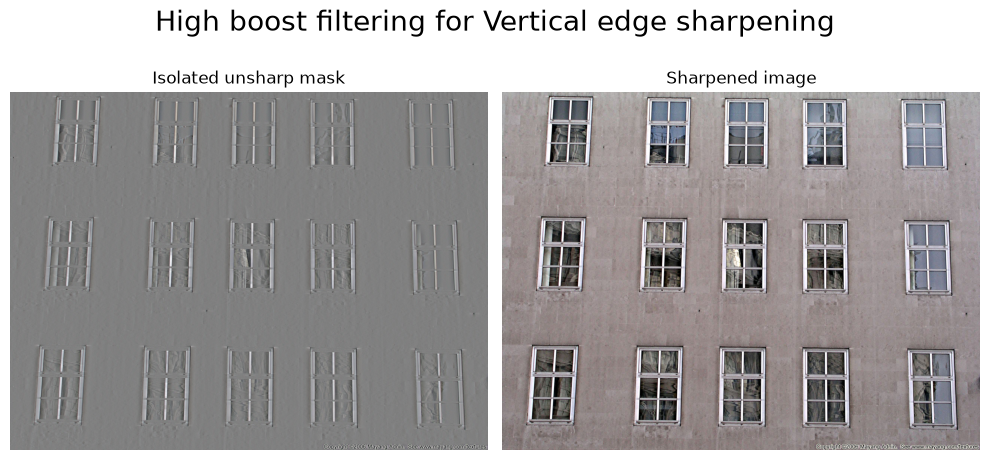

In [7]:
# compute unsharp mask
img_float = img1.astype(np.float32)
blur_float = blur_img.astype(np.float32)
unsharp_mask = img_float - blur_float

# apply high-boost filtering
k = 1.5
sharp_img = img_float + k * unsharp_mask
sharp_img = np.clip(sharp_img, 0, 255).astype(np.uint8)

# scaling to for appropriate mask display
mask_display = np.clip(unsharp_mask + 128, 0, 255).astype(np.uint8)

display_images(
    rows=1, cols=2,
    title="High boost filtering for Vertical edge sharpening",
    channels=[mask_display, sharp_img],
    channel_names=["Isolated unsharp mask", "Sharpened image"]
)

**Explanation**

- **Vertical edges:** Their intensity changes along the ***x-direction***. Since `sigma_x = 20` is large, the ***Gaussian strongly blurs across these edges***, creating a ***large difference \(Mask = Input - Blurred\)***. High-boost filtering therefore ***sharpens vertical edges***.

- **Horizontal edges:** Their intensity changes along the ***y-direction***. Since `sigma_y = 0.5` is small, there is ***very little blurring across these edges***. Hence they remain approximately the same, making the ***mask close to zero***, so horizontal edges remain ***largely unaffected***.

## Task 2: Image Enhancement Transformations (6 Marks)
Select and apply the appropriate spatial enhancement technique for three input images `image_two.jpg`, `image_three.jpg` and `image_four.jpg` (Assignment-2 resources).

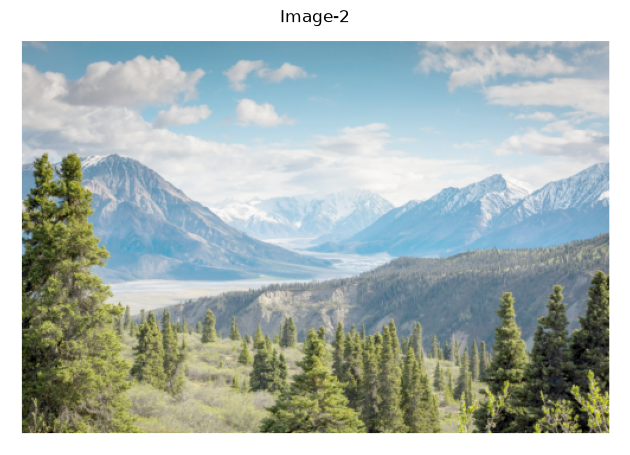

In [8]:
img2 = cv2.imread('resources/image_two.jpg')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.imshow(img2)
plt.title("Image-2")
plt.axis("off")
plt.tight_layout()

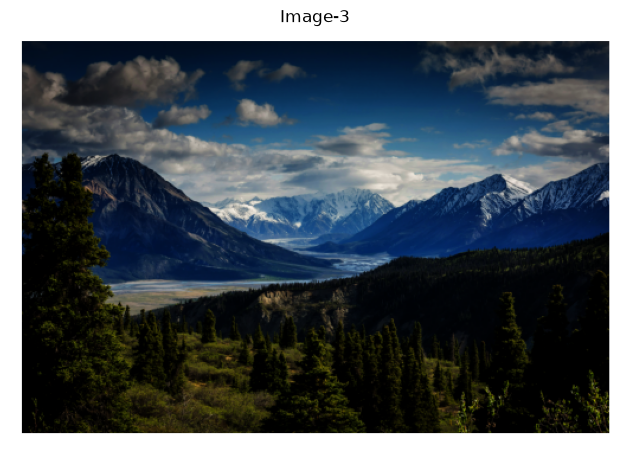

In [9]:
img3 = cv2.imread('resources/image_three.jpg')
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

plt.imshow(img3)
plt.title("Image-3")
plt.axis("off")
plt.tight_layout()

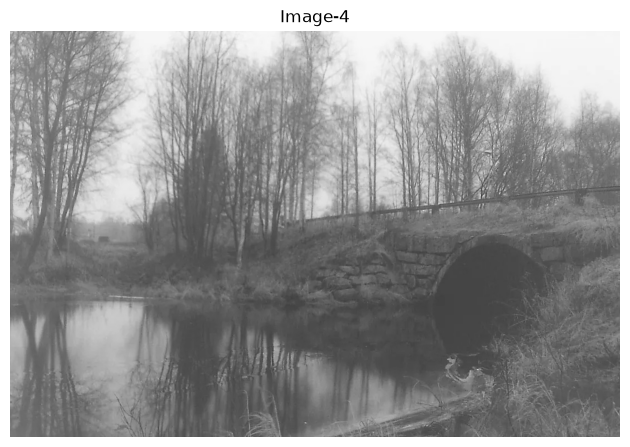

In [10]:
img4 = cv2.imread('resources/image_four.jpg')
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

plt.imshow(img4)
plt.title("Image-4")
plt.axis("off")
plt.tight_layout()

### Task 2.1 Implementation & Selection (6 Marks)

Analyse the contrast and intensity distribution of each provided image and apply one of the following techniques per image:
- Gamma Correction with `γ < 1`
- Gamma Correction with `γ > 1`
- Histogram Equalization

In [11]:
def gamma_correction(img, gamma=1.0):
    """
    Applies Gamma correction
        s = 255 * (r / 255) ^ gamma
    gamma < 1   => expands lower intensities -> brightens image
    gamma > 1   => compresses higher intensities -> darkens image
    gamma = 1   => no intensity change -> original image
    """
    img_norm = img / 255.0
    gamma_img = img_norm ** gamma
    gamma_img = np.uint8(gamma_img * 255.0)
    return gamma_img

def histogram_equalization(img):
    """
    Applies (normalized) Histogram equalization
        s = (L - 1) * (CDF(r) - CDF_min) / (N - CDF_min)
    where,
        L       = number of intensity levels
        CDF(r)  = cumulative distribution function at intensity r
        CDF_min = minimum non-zero CDF value
        N       = total number of pixels
    """
    # convert to grayscale if required
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    L = 256
    histogram = np.bincount(img.ravel(), minlength=L)   
    cdf = histogram.cumsum()                            
    cdf_min = cdf[cdf > 0][0]
    
    img_equalized = (cdf[img] - cdf_min) * (L - 1) / (img.size - cdf_min)
    img_equalized = np.uint8(img_equalized)
    return img_equalized


In [12]:
# utility method to plot intensity distribution of an image
def display_intensity_dist(img, img_name, color='blue'):
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    plt.figure(figsize=(15, 5))
    plt.hist(img_gray.ravel(), bins=255, range=(0,256), color=color, alpha=0.8)

    plt.title(f"Intensity Distribution of {img_name}")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.5)
    plt.tight_layout()

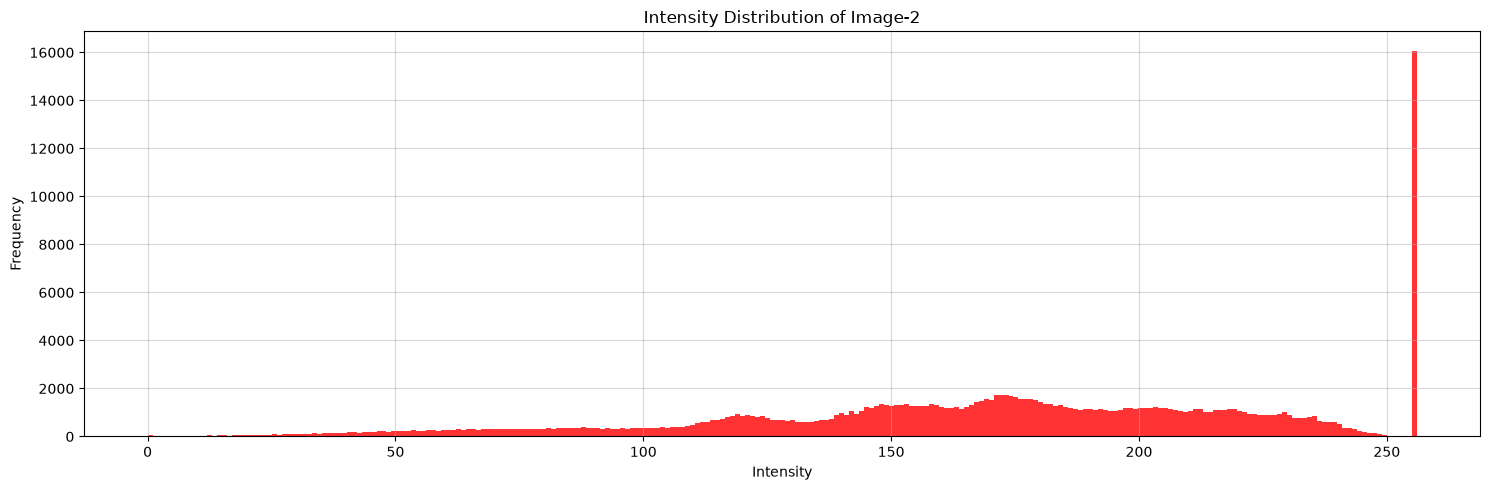

In [13]:
display_intensity_dist(img2, 'Image-2', 'red')

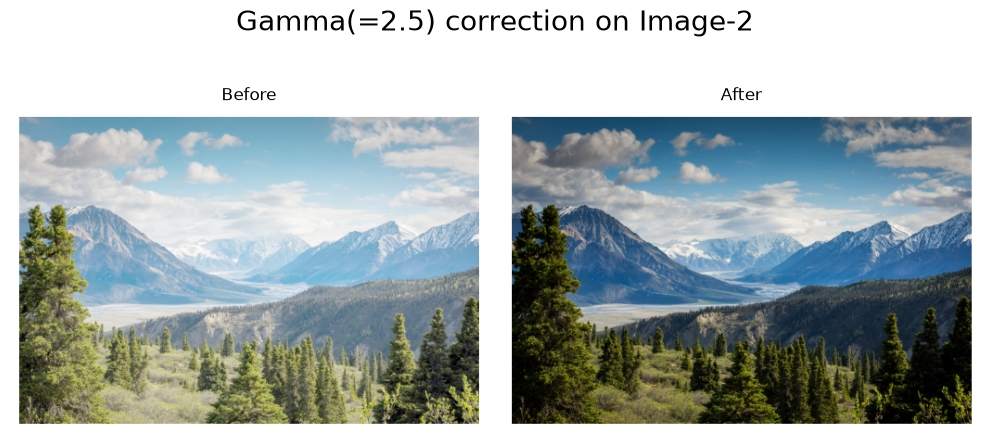

In [14]:
gamma = 2.5
img2_corrected = gamma_correction(img2, gamma)

display_images(
    rows=1, cols=2,
    channels=[img2, img2_corrected],
    title=f"Gamma(={gamma}) correction on Image-2"
)

**Enhancement technique for Image-2**

A `gamma = 2.5` was selected because ***Image-2 is relatively bright***, with many pixels concentrated at higher intensity levels. Since `gamma > 1`, gamma correction ***darkens the image by compressing higher intensity levels***, making it suitable for improving the overall intensity distribution.

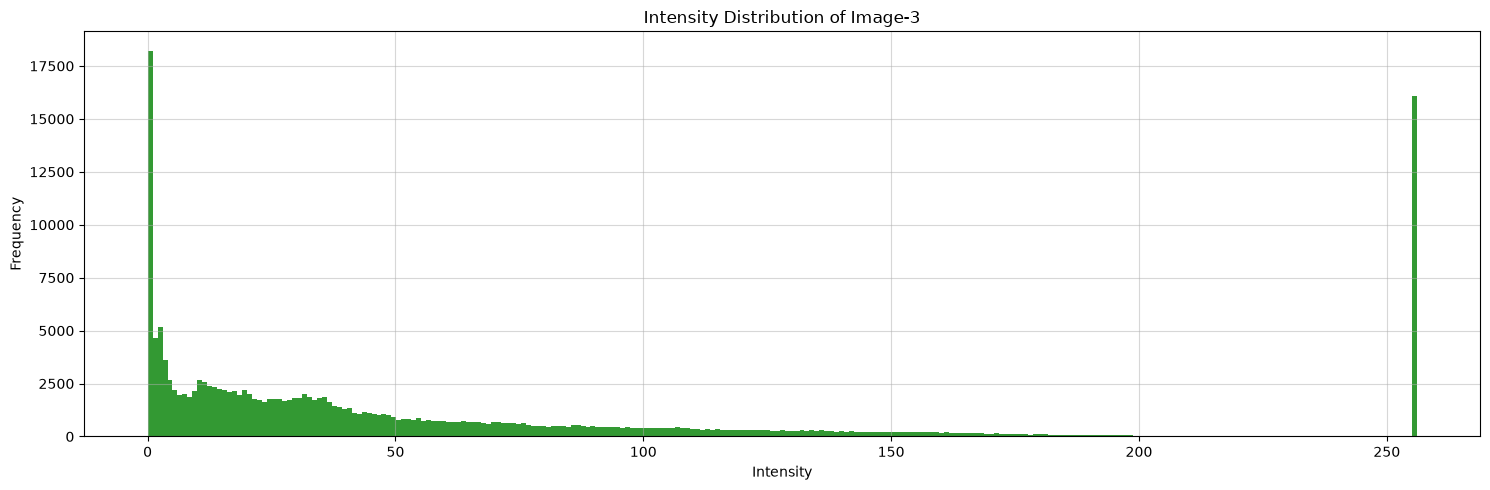

In [15]:
display_intensity_dist(img3, 'Image-3', 'green')

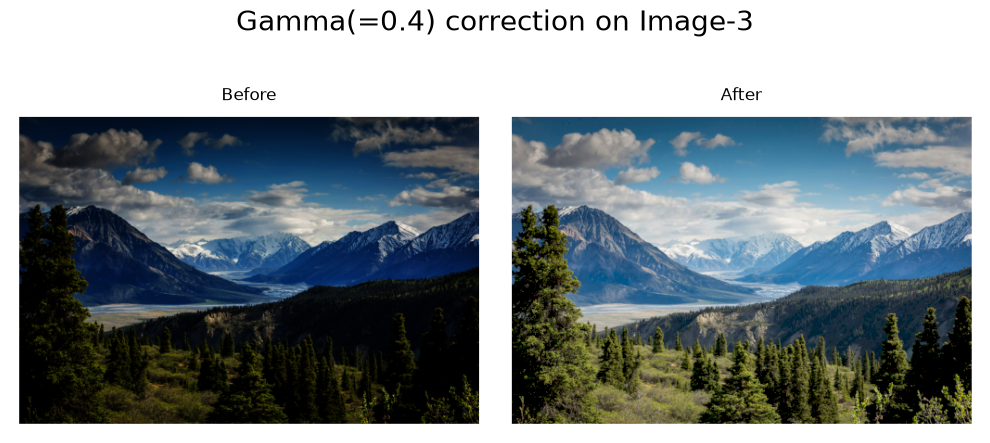

In [16]:
gamma = 0.4
img3_corrected = gamma_correction(img3, gamma)

display_images(
    rows=1, cols=2,
    channels=[img3, img3_corrected],
    title=f"Gamma(={gamma}) correction on Image-3"
)

**Enhancement technique for Image-3**

A `gamma = 0.4` was selected because ***Image-3 is relatively dark***, with many pixels concentrated at lower intensity levels. Since `gamma < 1`, gamma correction ***brightens the image by expanding lower intensity levels***, making it suitable for improving the overall intensity distribution.

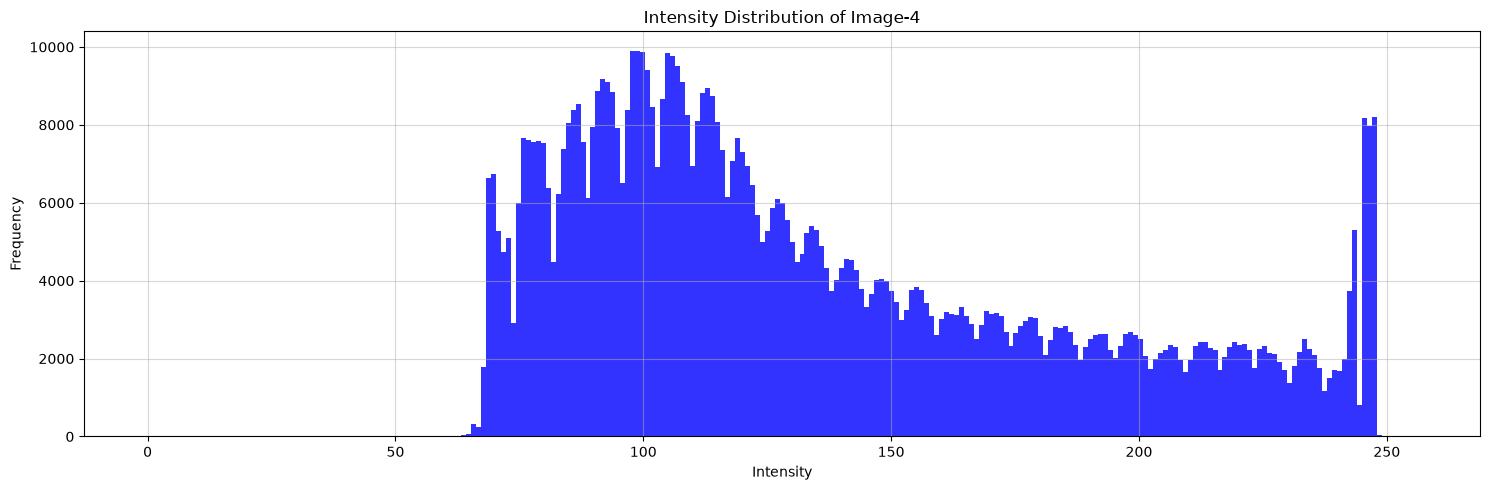

In [17]:
display_intensity_dist(img4, 'Image-4', 'blue')

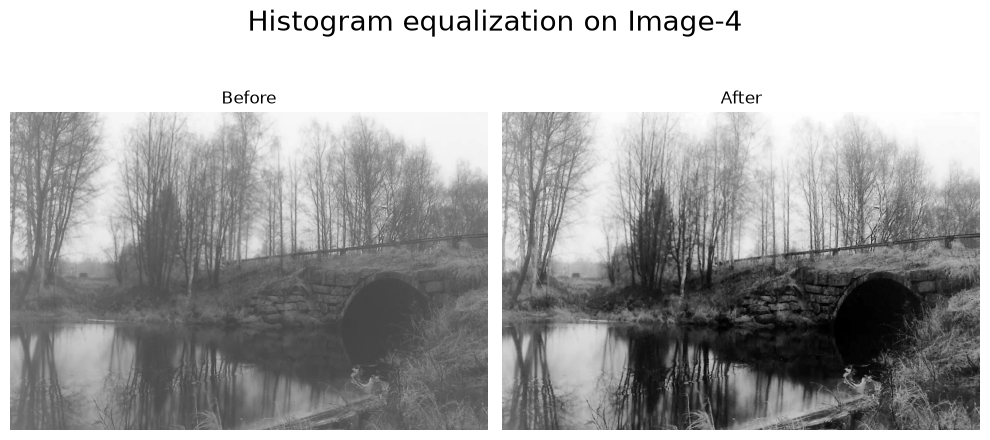

In [18]:
img4_corrected = histogram_equalization(img4)

display_images(
    rows=1, cols=2,
    channels=[img4, img4_corrected],
    title=f"Histogram equalization on Image-4"
)

**Enhancement technique for Image-4**

`Histogram Equalization` was selected because Image-4 has a ***compressed intensity distribution***, with most pixels concentrated in the mid-intensity range. ***It redistributes the intensity levels to enhance the overall contrast*** of the image.

## Task 3: Edge-Preserving Filtering for Color Images (8 Marks)

Use `image_five.jpg` and `image_six.jpg` (Assignment-2 resources)

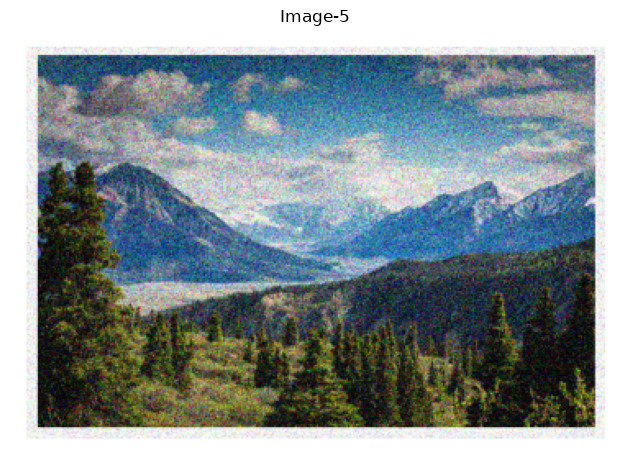

In [19]:
img5 = cv2.imread('resources/image_five.jpg')
img5 = cv2.cvtColor(img5, cv2.COLOR_BGR2RGB)

plt.imshow(img5)
plt.title("Image-5")
plt.axis("off")
plt.tight_layout()

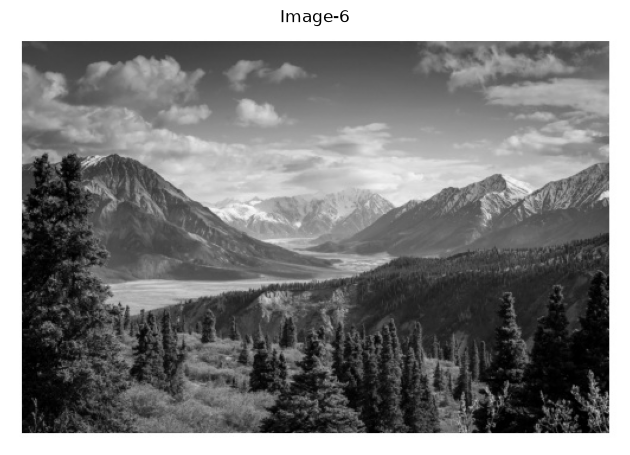

In [20]:
img6 = cv2.imread('resources/image_six.jpg')
img6 = cv2.cvtColor(img6, cv2.COLOR_BGR2RGB)

plt.imshow(img6)
plt.title("Image-6")
plt.axis("off")
plt.tight_layout()

### Task 3.1 Bilateral Filtering on Colour Image (3 Marks)

- Apply bilateral filtering to `image_five` (noisy RGB colour image). Compute spatial domain weights using spatial distance and range weights.

In [21]:
def bilateral_filter(image, kernel_size, sigma_spatial, sigma_intensity):
    """
    Bilateral filtering for an RGB image.
    Spatial weight:             G_s(m,n) = exp(-(m^2 + n^2) / (2 * sigma_spatial^2))
    RGB colour distance:        ||I(i,j)-I(i+m,j+n)|| = sqrt((R_ij - R_i+m,j+n)^2 + (G_ij - G_i+m,j+n)^2 + (B_ij - B_i+m,j+n)^2)
    Range weight:               G_r((i,j),(i+m,j+n)) = exp(-||I(i,j) - I(i+m,j+n)||^2 / (2 * sigma_intensity^2))
    Combined bilateral weight:  w(i,j,m,n) = G_s(m,n) * G_r((i,j), (i+m,j+n))
    Normalization factor:       W_i,j = SUM m,n [w(i,j,m,n)]
    Bilateral output:           I_out(i,j) = SUM m,n [w(i,j,m,n) * I(i+m, j+n)] / W_i,j
    """
    image_float = image.astype(np.float32)
    half_size = kernel_size // 2
    output_image = np.zeros_like(image_float)

    # pre-compute spatial weights G_s(x,y)
    y, x = np.mgrid[-half_size:half_size+1, -half_size:half_size+1]
    spatial_kernel = np.exp(-(x**2 + y**2) / (2 * sigma_spatial**2))

    # pad the RGB image once
    padded_image = np.pad(image_float, ((half_size, half_size), (half_size, half_size), (0, 0)), mode='edge')

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # calculate range weights
            region = padded_image[i:i + kernel_size, j:j + kernel_size]
            intensity_diff = region - image_float[i, j]
            color_distance = np.sqrt(np.sum(intensity_diff**2, axis=2))
            intensity_weights = np.exp(-(color_distance**2) / (2 * sigma_intensity**2))
            combined_weights = spatial_kernel * intensity_weights
            normalization_factor = np.sum(combined_weights)
            
            if normalization_factor == 0:
                output_image[i, j] = image_float[i, j]
            else:
                output_image[i, j] = np.sum(region * combined_weights[:, :, np.newaxis], axis=(0, 1)) / normalization_factor
                
    return output_image.astype(np.uint8)

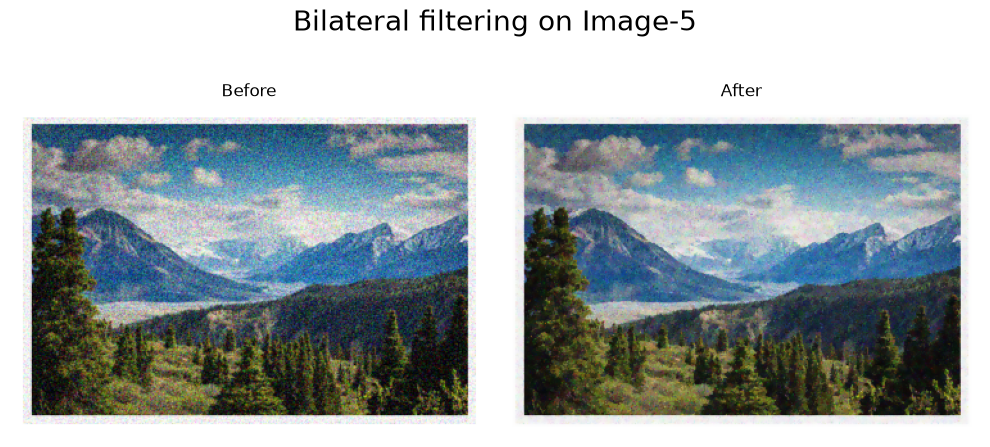

In [26]:
img5_bilateral = bilateral_filter(img5, kernel_size=5, sigma_spatial=2, sigma_intensity=25)

display_images(
    rows=1, cols=2,
    channels=[img5, img5_bilateral],
    title="Bilateral filtering on Image-5"
)

### Task 3.2 Joint Bilateral Filtering (3 Marks)

- Apply joint bilateral filtering to `image_five` using `image_six` as the guidance image. Compute range weights using intensity differences from `image_six`.

In [23]:
def joint_bilateral_filter(image, guidance, kernel_size, sigma_spatial, sigma_intensity):
    """
    Joint bilateral filtering for an RGB image using a grayscale guidance image.
    Spatial weight:             G_s(m,n) = exp(-(m^2 + n^2) / (2 * sigma_spatial^2))
    Guidance intensity diff:    |G(i,j) - G(i+m,j+n)|
    Range weight:               G_r((i,j),(i+m,j+n)) = exp(-|G(i,j) - G(i+m,j+n)|^2 / (2 * sigma_intensity^2))
    Combined joint weight:      w(i,j,m,n) = G_s(m,n) * G_r((i,j),(i+m,j+n))
    Normalization factor:       W_i,j = SUM m,n [w(i,j,m,n)]
    Joint bilateral output:     I_out(i,j) = SUM m,n [w(i,j,m,n) * I(i+m,j+n)] / W_i,j
    """
    image_float = image.astype(np.float32)
    guidance_float = guidance.astype(np.float32)
    half_size = kernel_size // 2
    output_image = np.zeros_like(image_float)

    # pre-compute spatial weights G_s(x,y)
    y, x = np.mgrid[-half_size:half_size+1, -half_size:half_size+1]
    spatial_kernel = np.exp(-(x**2 + y**2) / (2 * sigma_spatial**2))

    # pad target RGB image and guidance grayscale image once
    padded_image = np.pad(image_float, ((half_size, half_size), (half_size, half_size), (0, 0)), mode='edge')
    padded_guidance = np.pad(guidance_float, ((half_size, half_size), (half_size, half_size)), mode='edge')

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_image[i:i + kernel_size, j:j + kernel_size]
            guidance_region = padded_guidance[i:i + kernel_size, j:j + kernel_size]

            # calculate range weights from guidance intensity differences
            intensity_diff = guidance_region - guidance_float[i, j]
            intensity_weights = np.exp(-(intensity_diff**2) / (2 * sigma_intensity**2))
            combined_weights = spatial_kernel * intensity_weights
            normalization_factor = np.sum(combined_weights)

            if normalization_factor == 0:
                output_image[i, j] = image_float[i, j]
            else:
                output_image[i, j] = np.sum(region * combined_weights[:, :, np.newaxis], axis=(0, 1)) / normalization_factor

    return output_image.astype(np.uint8)

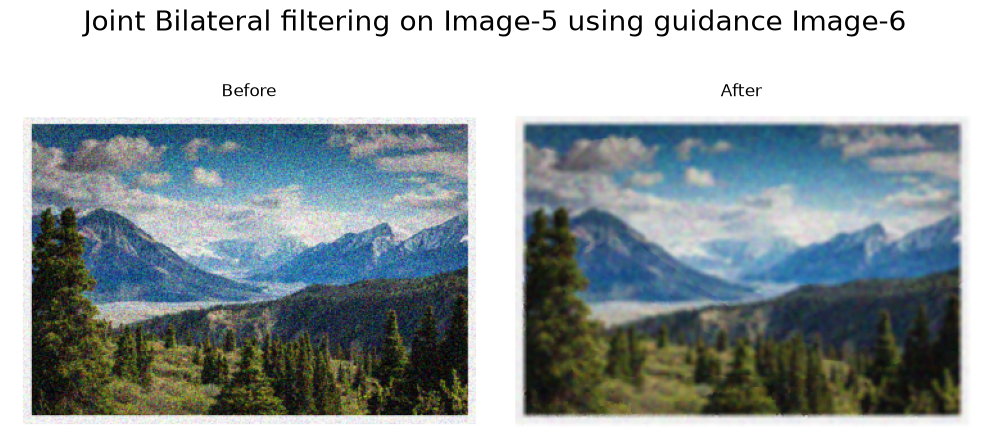

In [27]:
img6_gray = cv2.cvtColor(img6, cv2.COLOR_RGB2GRAY)
img5_joint_bilateral = joint_bilateral_filter(img5, img6_gray, kernel_size=5, sigma_spatial=2, sigma_intensity=25)

display_images(
    rows=1, cols=2,
    channels=[img5, img5_joint_bilateral],
    title="Joint Bilateral filtering on Image-5 using guidance Image-6"
)

### Task 3.3 Results and Analysis (2 Marks)

- Display the results from both filtering approaches and answer the following and explain the difference in the results of bilateral filtering and joint bilateral filtering.

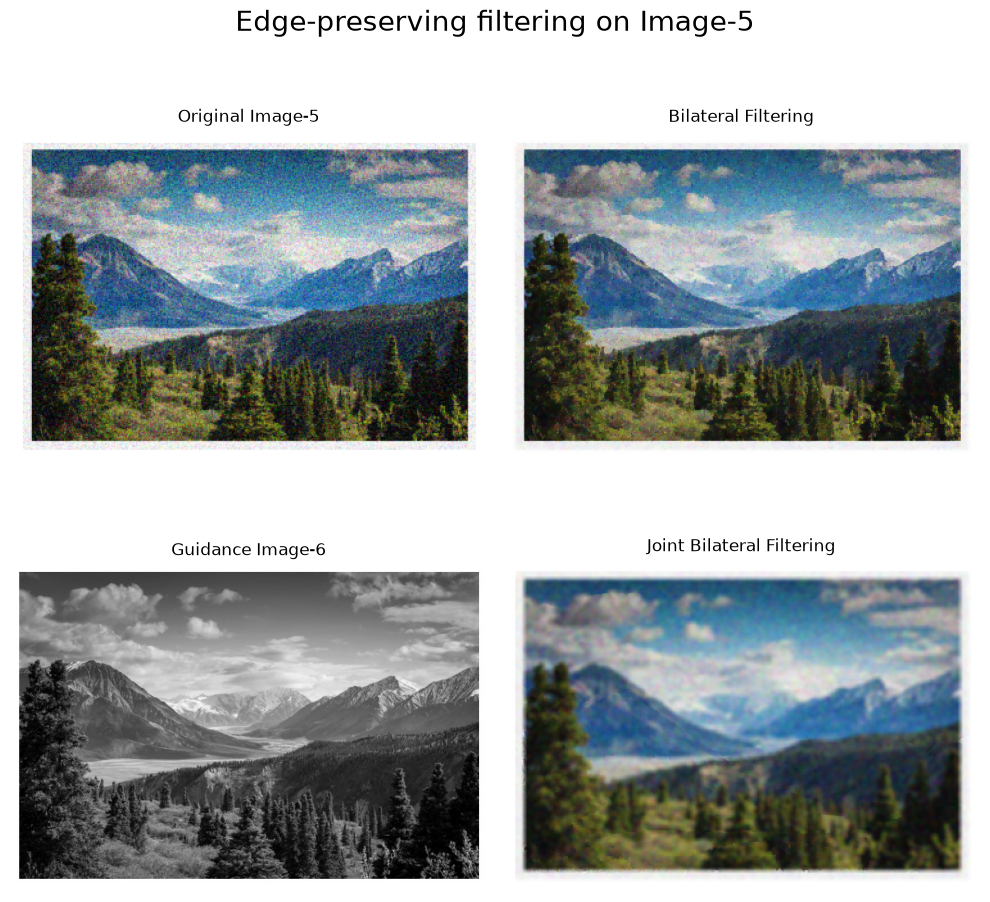

In [28]:
display_images(
    rows=2, cols=2,
    channels=[img5, img5_bilateral, img6, img5_joint_bilateral],
    channel_names=["Original Image-5", "Bilateral Filtering", "Guidance Image-6", "Joint Bilateral Filtering"],
    title="Edge-preserving filtering on Image-5"
)

**Explanation**
- ***Bilateral filtering*** smooths `Image-5` while preserving edges using the intensity information of `Image-5` itself.
- ***Joint bilateral filtering*** uses `Image-6` as a ***guidance image*** to determine which pixels should be smoothed together. The sharper guidance preserves major boundaries while allowing stronger averaging within similar regions.
- In the results, ***joint bilateral filtering gives stronger smoothing*** than bilateral filtering while preserving the major structures, although some fine details are lost.

---
End of the assignment